In [1]:
import yaml
import torch
import time
import matplotlib.pyplot as plt


from sfmpe.tasks.StochVol import StochVolTask


config_path = './configs/sv_config.yaml'
with open(config_path) as f:
    config = yaml.safe_load(f)
device = 'cpu'
task = StochVolTask(config, device)
logger = task.logger
logger.info("Starting StochVol task")


2026-05-02 20:18:25,462 - StochVol - INFO - Starting StochVol task


In [2]:
from sfmpe.inference.fm_estimator import FlowMatchingEstimator
from sfmpe.flow.flow_model import FlowModel
from sfmpe.flow.velocity import SimpleVelocityField
from sfmpe.flow.path import AffinePath
from sfmpe.core.distributions import Uniform, Normal


init_dist = Normal(dim=task.theta_dim)
velocity_model = SimpleVelocityField(task.theta_dim, task.data_dim, 64)
path = AffinePath() #time_dist=torch.distributions.Beta(0.8, 0.5)
flow_model = FlowModel(velocity_model, init_dist, path)
logger.info("Initialized flow model")

optimizer = torch.optim.Adam([
                        {"params": task.summary.parameters(), "lr":1e-5},
                        {"params": flow_model.parameters(), "lr":1e-5}
                        ])
loss_fn = torch.nn.MSELoss()

fm_estimator = FlowMatchingEstimator(flow_model, optimizer, loss_fn)
logger.info("Initialized flow matching estimator")

2026-05-02 20:18:26,363 - StochVol - INFO - Initialized flow model
2026-05-02 20:18:27,501 - StochVol - INFO - Initialized flow matching estimator


In [3]:
from sfmpe.inference.sequential.round_manager import RoundManager
from sfmpe.inference.sequential.proposal import Proposal, ProposalParams

theta_0, x_0 = task.simulate_dataset((1,))
# theta_0 = task.prior.sample((1,))
# x_0 = task.summary(task.simulate(theta_0))
# theta_0 = torch.tensor([[1.6667, 0.4016]])
# x_0 = task.summarize(task.simulate(theta_0))
# theta_0, x_0 = theta_0.expand(5, -1), x_0.expand(5, -1)
task.logger.info(f"Starting SFMPE for theta: {theta_0}, x: {x_0}")
params = ProposalParams()
params.task = task
params.method = "Truncated"
params.theta_dim = task.theta_dim
params.theta_0 = theta_0
params.x_0 = x_0
params.method_params = {"scale": 0.9}


2026-05-02 20:18:27,995 - StochVol - INFO - Starting SFMPE for theta: tensor([[-0.1146,  0.8676,  0.1979, -1.8019]]), x: tensor([[-0.1810, -1.8111, -0.4620,  1.2033,  0.0154]])


2026-05-02 20:18:28,013 - StochVol - INFO - RoundManager initialized with device: cpu
2026-05-02 20:18:28,014 - StochVol - INFO - Task: StochVolTask
2026-05-02 20:18:28,015 - StochVol - INFO - Estimator: FlowMatchingEstimator
2026-05-02 20:18:28,016 - StochVol - INFO - Starting sequential training with 10 rounds
2026-05-02 20:18:28,018 - StochVol - INFO - Simulations per round: 10000
2026-05-02 20:18:28,019 - StochVol - INFO - Training kwargs: {'path': './models/SV_2026-05-02_20_18_28.pth.tar.gz', 'epochs': 2000, 'show_every': 500}
2026-05-02 20:18:28,019 - StochVol - INFO - --- Round 0/10 ---
2026-05-02 20:18:28,020 - StochVol - INFO - Starting round 0 with 10000 simulations
2026-05-02 20:18:28,022 - StochVol - DEBUG - Proposal distribution: <sfmpe.tasks.StochVol.StochVolPrior object at 0x000002141C13DE40>
2026-05-02 20:18:28,028 - StochVol - INFO - 19 left to sample
2026-05-02 20:18:28,036 - StochVol - INFO - 0 left to sample
2026-05-02 20:18:28,037 - StochVol - DEBUG - 2, torch.Size

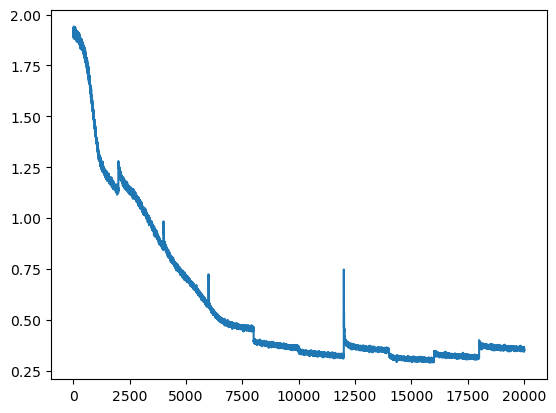

In [4]:
datetime = time.strftime("%Y-%m-%d_%H_%M_%S")
path = f"./models/SV_{datetime}.pth.tar.gz"

num_rounds = 10
sims_per_round = 10000
epochs = 2000
show_every = 500

manager = RoundManager(task, fm_estimator, params)

code = manager.run_sequential(num_rounds=num_rounds,
                       sims_per_round=sims_per_round,
                       path=path, epochs=epochs, 
                       show_every=show_every)

loss = manager.losses
plt.plot(loss)

True: tensor([[-0.1146,  0.8676,  0.1979, -1.8019]]) - Mean: tensor([[ 1.8255e-04,  8.6090e-01,  1.1830e-01, -1.4918e+00]]) - Std: tensor([[0.2008, 0.1072, 0.0490, 1.0017]])
True: tensor([[-0.1146,  0.8676,  0.1979, -1.8019]]) - Mean: tensor([[-0.0250,  0.6428,  0.4095, -2.1592]]) - Std: tensor([[0.5271, 0.2132, 0.2137, 0.8825]])
True: tensor([[-0.1146,  0.8676,  0.1979, -1.8019]]) - Mean: tensor([[ 0.0348,  0.6077,  0.3863, -1.0404]]) - Std: tensor([[0.4664, 0.2126, 0.2076, 0.7454]])
True: tensor([[-0.1146,  0.8676,  0.1979, -1.8019]]) - Mean: tensor([[-0.0599,  0.5914,  0.3491, -0.8790]]) - Std: tensor([[0.3846, 0.2079, 0.1945, 0.6474]])
True: tensor([[-0.1146,  0.8676,  0.1979, -1.8019]]) - Mean: tensor([[-0.0861,  0.5399,  0.3705, -1.0765]]) - Std: tensor([[0.3580, 0.1934, 0.1977, 0.5106]])
True: tensor([[-0.1146,  0.8676,  0.1979, -1.8019]]) - Mean: tensor([[-0.0629,  0.5206,  0.3331, -1.0699]]) - Std: tensor([[0.3424, 0.1874, 0.1916, 0.4457]])
True: tensor([[-0.1146,  0.8676,  0.

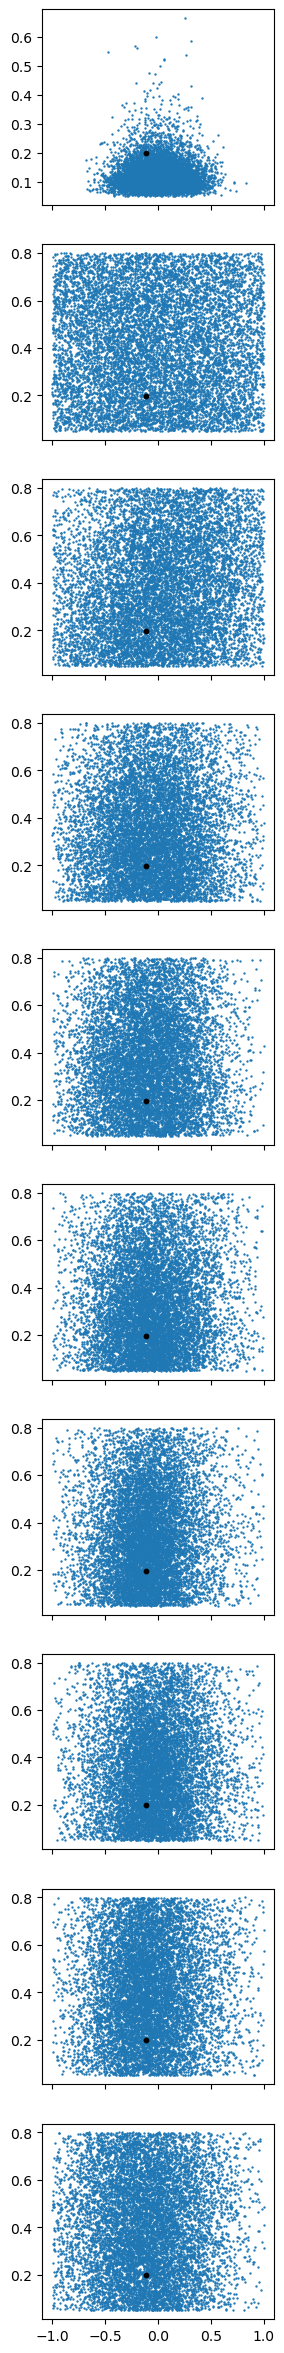

In [5]:
sim_store = manager.store

x = 0
y = 2
rounds = range(num_rounds)
# rounds = [0, num_rounds-1]

_, ax = plt.subplots(len(rounds), 1, sharex=True, figsize=(3, 3 * len(rounds)))

for r, i in zip(rounds, range(len(rounds))):
    theta, _ = sim_store.theta[r], sim_store.x[r]
    ax[i].scatter(theta[:, :, x], theta[:, :, y], s=0.5)#, alpha=(r+1) / len(rounds))
    ax[i].scatter(theta_0[:, x], theta_0[:, y], s=10, color="black")
    # ax.scatter(theta[:, :, x], theta[:, :, y], s=0.5)#, alpha=(r+1) / len(rounds))
    # ax.scatter(theta_0[:, x], theta_0[:, y], s=10, color="black")
    
    # ax[r].set_xlim(0, 2.5)
    # ax[r].set_ylim(0, 0.5)
    msg = f"True: {theta_0} - Mean: {theta.mean(dim=0)} - Std: {theta.std(dim=0)}"
    print(msg)
    # logger.info(msg)
# plt.savefig("output/sv_posterior.png")

2026-05-02 20:29:46,282 - StochVol - INFO - Building posterior...


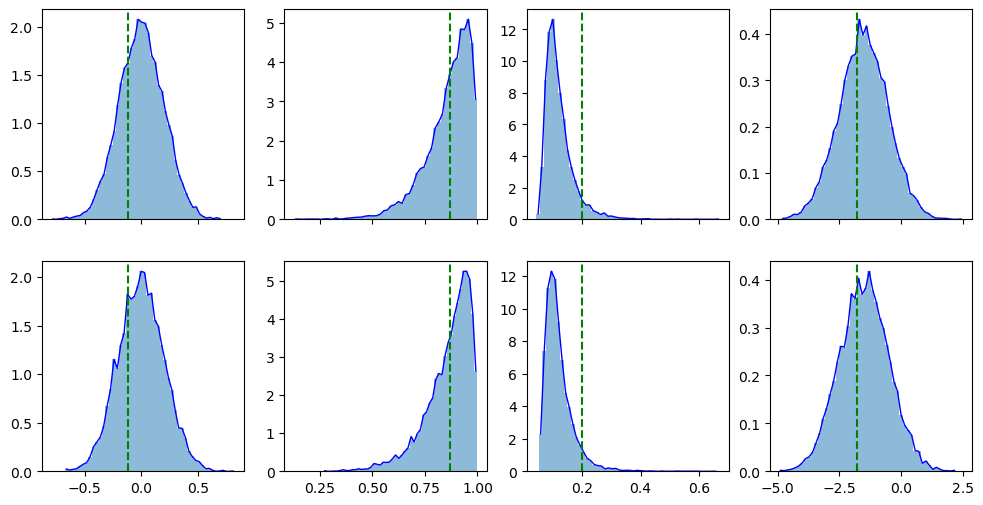

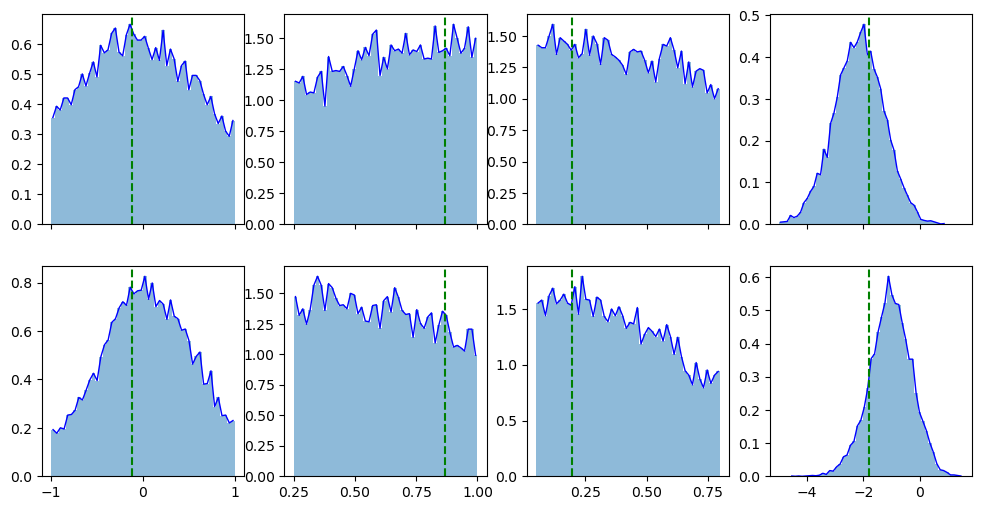

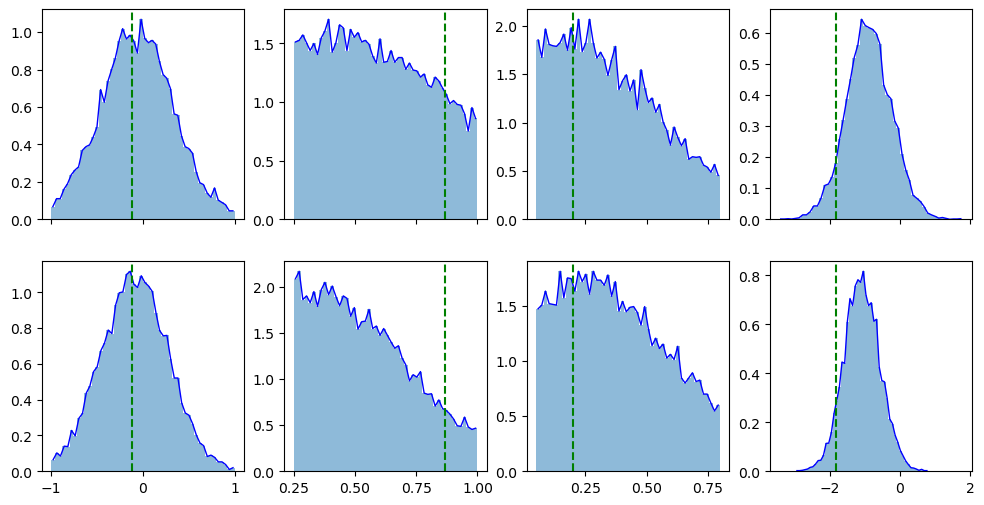

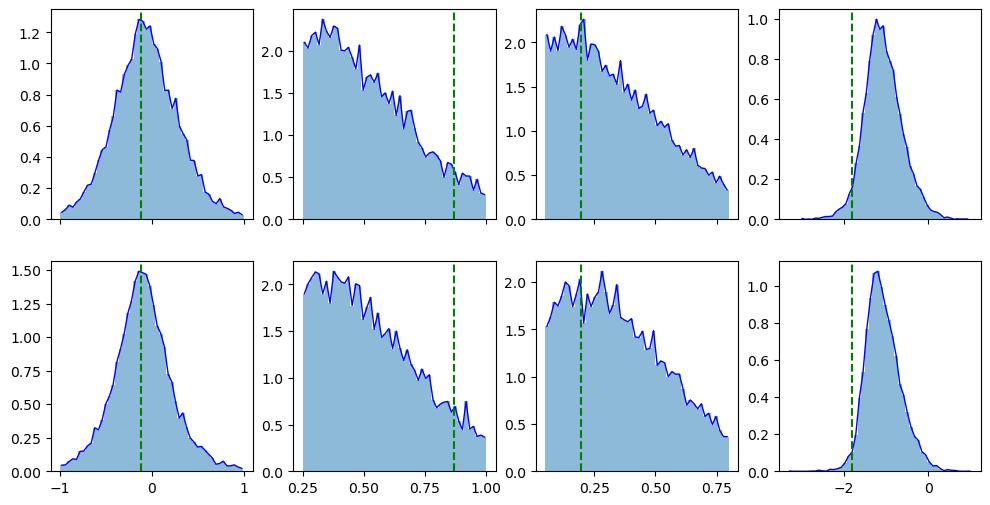

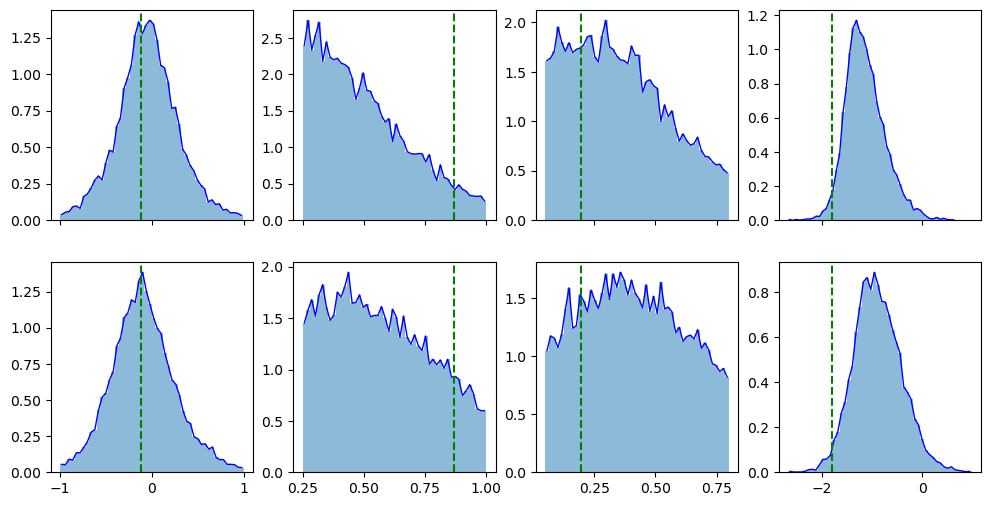

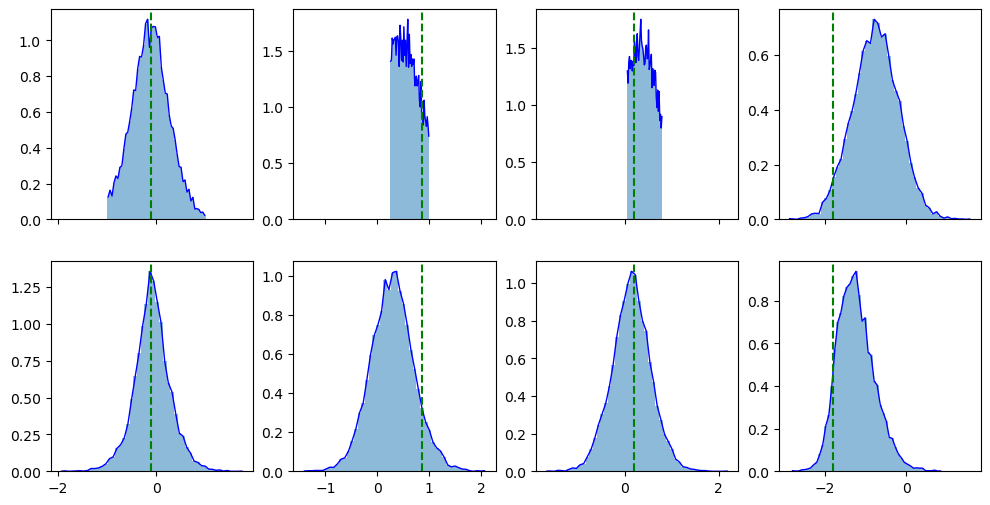

In [6]:
posterior = manager.build_posterior()

def dist_comparison(dist1, dist2, true_param=None):
    _, ax = plt.subplots(2, task.theta_dim, sharex='col', figsize=(3*task.theta_dim, 3*2))
    for j in range(task.theta_dim):
        for thetas, i in zip([dist1, dist2], (0, 1)):
            counts, bins, patches = ax[i][j].hist(thetas[:, :, j], bins=50, alpha=0.5, density=True)

            bin_centers = (bins[:-1] + bins[1:]) / 2

            ax[i][j].plot(bin_centers, counts, 'b-', linewidth=1)

            if true_param is not None:
                ax[i][j].axvline(x=true_param[:, j], linestyle='--', color='green')

dist_comparison(task.prior.sample((10000, 1)), sim_store.theta[0], true_param=theta_0)
dist_comparison(sim_store.theta[1], sim_store.theta[2], true_param=theta_0)
dist_comparison(sim_store.theta[3], sim_store.theta[4], true_param=theta_0)
dist_comparison(sim_store.theta[5], sim_store.theta[6], true_param=theta_0)
dist_comparison(sim_store.theta[7], sim_store.theta[8], true_param=theta_0)
dist_comparison(sim_store.theta[9], posterior.sample((10000,)), true_param=theta_0)
# dist_comparison(task.prior.sample((10000, 1)), posterior.sample((10000,)), true_param=theta_0)

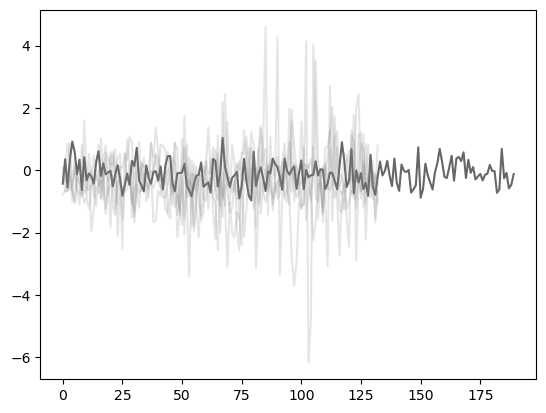

In [7]:
obs_real = task.simulate(theta_0).squeeze(-1)
obs = task.simulate(theta).squeeze(-1)
plt.plot(obs_real[0], color='black', alpha=0.6)
for i in range(5):
    plt.plot(obs[i, 0], color='grey', alpha=0.2)
plt.show()

In [8]:
# from sfmpe.tasks.StochVol import HandmadeSummary
# hm_summary = HandmadeSummary({})

# likelyhood = []
# for i in range(1000):
#     obs_0 = task.simulate(theta_0.expand(1, -1))
#     likelyhood.append(task.summary(obs_0))
# likelyhood = torch.cat(likelyhood)

In [9]:
# j = 2
# counts, bins, patches = plt.hist(likelyhood[:, j].detach(), bins=50, alpha=0.5)

# bin_centers = (bins[:-1] + bins[1:]) / 2

# plt.plot(bin_centers, counts, 'r-o', linewidth=2, markersize=4)
# plt.axvline(x=x_0[:, j].detach(), linestyle='--', color='green')

In [10]:
# theta, x = task.simulate_dataset((5000,))
# import corner

# # for i in range(theta.shape[0]):
# samples = theta.numpy()
# fig = corner.corner(samples, bins=40, levels=[0.5], labels=['mu', 'phi', 'sigma', 'm'],
#                     plot_datapoints=False, plot_contours=True, smooth=1)

In [11]:
# theta = posterior.sample((10000,))

# # for i in range(theta.shape[0]):
# samples = theta.numpy()
# fig = corner.corner(samples, bins=40, levels=[0.5], labels=['mu', 'phi', 'sigma', 'm'],
#                     plot_datapoints=False, plot_contours=True, smooth=1)

In [12]:

# samples = likelyhood.detach().numpy()
# fig = corner.corner(samples, bins=40, levels=[0.5], labels=[f"feature_{i}" for i in range(likelyhood.shape[-1])],
#                     plot_datapoints=False, plot_contours=True, smooth=1)

In [13]:
# from sbi.inference import SMCABC

# smc = SMCABC(simulator=lambda theta: task.summary(task.simulator.simulate(theta)),
#              prior=task.prior)
# output = smc(x_0, 
#     num_particles=1000,
#     num_initial_pop=5000,
#     num_simulations=5000,
#     epsilon_decay=0.5)
# plt.scatter(output[:, 0], output[:, 1], s=1)
# plt.scatter(theta_0[:, 0], theta_0[:, 1])

In [14]:
# samples = output.numpy()
# fig = corner.corner(samples, bins=40, levels=[0.5], labels=['mu', 'phi', 'sigma', 'm'],
#                     plot_datapoints=False, plot_contours=True, smooth=1)

In [15]:
# dist_comparison(task.prior.sample((1000, 1)), output.unsqueeze(-2), true_param=theta_0)